<a href="https://colab.research.google.com/github/DaihSeven/deteccao-anomalias-python/blob/main/Deteccao_de_Anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Anomalias em Transações Financeiras

Projeto desenvolvido para demonstrar técnicas básicas de Machine Learning na identificação de transações suspeitas.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

In [4]:
dados = {
    "valor":[
        150,
        9800,
        320,
        8700,
        80,
        12000,
        450,
        9200,
        210,
        5000
    ],

    "hora":[
        10,
        3,
        15,
        2,
        12,
        1,
        14,
        4,
        18,
        23
    ],

    "transacoes_dia":[
        2,
        18,
        3,
        15,
        1,
        22,
        4,
        20,
        2,
        12
    ],

    "novo_dispositivo":[
        0,
        1,
        0,
        1,
        0,
        1,
        0,
        1,
        0,
        1
    ],

    "anomalia":[
        0,
        1,
        0,
        1,
        0,
        1,
        0,
        1,
        0,
        1
    ]
}

df = pd.DataFrame(dados)

df.head()

,valor,hora,transacoes_dia,novo_dispositivo,anomalia
0,150,10,2,0,0
1,9800,3,18,1,1
2,320,15,3,0,0
3,8700,2,15,1,1
4,80,12,1,0,0


In [5]:
df.info()

df.describe()

df["anomalia"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   valor             10 non-null     int64
 1   hora              10 non-null     int64
 2   transacoes_dia    10 non-null     int64
 3   novo_dispositivo  10 non-null     int64
 4   anomalia          10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


,count
anomalia,
0,5
1,5


In [6]:
X = df.drop("anomalia", axis=1)

y = df["anomalia"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [8]:
modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [9]:
pred = modelo.predict(X_test)

In [10]:
print("Acurácia")

print(accuracy_score(y_test,pred))

print()

print(classification_report(y_test,pred))

Acurácia
1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [11]:
cm = confusion_matrix(y_test,pred)

print(cm)

[[1 0]
 [0 2]]


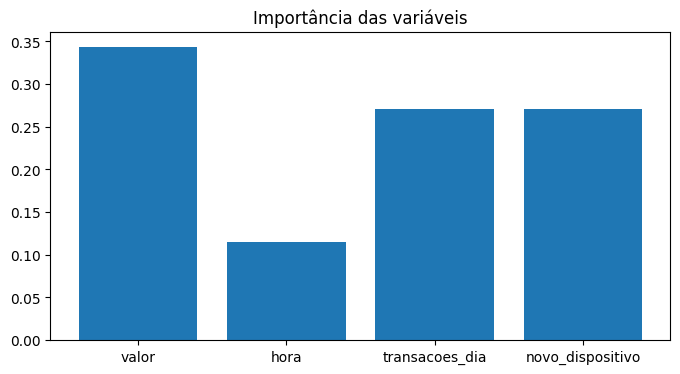

In [12]:
plt.figure(figsize=(8,4))

plt.bar(
    X.columns,
    modelo.feature_importances_
)

plt.title("Importância das variáveis")

plt.show()

Conclusão

O modelo conseguiu identificar padrões entre transações normais e suspeitas.

Mesmo utilizando um conjunto de dados pequeno, foi possível aplicar todas as etapas de um pipeline de Machine Learning:

• preparação dos dados

• treinamento

• avaliação

• interpretação dos resultados